# Travel Planner Assistant
This notebook filters travel destinations based on budget, type, and ratings.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# 1. Load dataset
df = pd.read_csv("travel_500.csv")
print(f"Dataset loaded successfully with {len(df)} records.")
df.head()

Dataset loaded successfully with 500 records.


,destination,cost,rating,type,location,days,best_time,transport
0,Kasol,20308,4.0,adventure,India,2,Oct-Mar,Flight/Train
1,Varanasi,21687,4.5,adventure,India,10,May-Sep,Flight
2,Goa,18799,3.9,adventure,India,8,May-Sep,Car
3,Kodaikanal,21646,4.5,adventure,India,3,Sep-Apr,Bus/Car
4,Spiti Valley,13717,4.6,adventure,India,2,Nov-Feb,Flight


### Apply Filters
Set your preferences here to filter the dataset.

In [6]:
# Inputs for filtering (Interactive CLI)
print("🌍 Welcome to the Travel Planner Assistant CLI!")

try:
    budget_input = input("Enter maximum budget (default 15000): ")
    max_budget = int(budget_input) if budget_input.strip() else 15000
except ValueError:
    print("Invalid input. Using default budget of 15000.")
    max_budget = 15000

type_input = input("Enter preferred travel types (comma separated, e.g., adventure,chill) [default both]: ")
if type_input.strip():
    preferred_types = [t.strip().lower() for t in type_input.split(',')]
else:
    preferred_types = ['adventure', 'chill']

try:
    rating_input = input("Enter minimum rating (e.g., 4.0) [default 4.2]: ")
    min_rating = float(rating_input) if rating_input.strip() else 4.2
except ValueError:
    print("Invalid input. Using default rating of 4.2.")
    min_rating = 4.2

print("\n--- Applying Filters (AND conditions) ---")
print(f"Budget: <= {max_budget}")
print(f"Types: {preferred_types}")
print(f"Min Rating: >= {min_rating}\n")

# 2. Filter by budget, type (AND condition), and rating
filtered_df = df[
    (df['cost'] <= max_budget) & 
    (df['type'].isin(preferred_types)) &
    (df['rating'] >= min_rating)
]

# 3. Sort by rating (descending)
sorted_df = filtered_df.sort_values(by='rating', ascending=False)

# 4. Show top destinations
top_destinations = sorted_df.head(10)
top_destinations

### Generate Recommendations Chart
Visualizing the Cost vs Rating of the top recommended destinations.

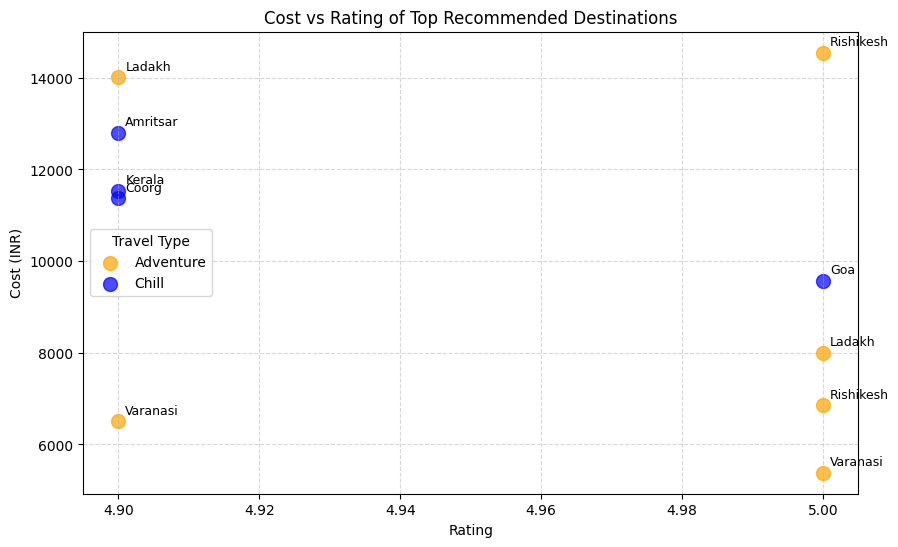

In [8]:
if not top_destinations.empty:
    plt.figure(figsize=(10, 6))
    
    colors = {'adventure': 'orange', 'chill': 'blue'}
    
    for t in preferred_types:
        subset = top_destinations[top_destinations['type'] == t]
        if not subset.empty:
            plt.scatter(subset['rating'], subset['cost'], 
                        c=colors.get(t, 'green'), label=t.capitalize(), 
                        s=100, alpha=0.7)
            
    for i, row in top_destinations.iterrows():
        plt.annotate(row['destination'], (row['rating'], row['cost']), 
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
            
    plt.xlabel("Rating")
    plt.ylabel("Cost (INR)")
    plt.title("Cost vs Rating of Top Recommended Destinations")
    plt.legend(title="Travel Type")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()
else:
    print("No destinations match your criteria.")